# MLP Probe Analysis — Multi-Turn Jailbreak Representations

This notebook trains MLP probes on hidden-state representations to study how
the model internally represents successful jailbreaks across three attack frameworks
(Crescendo, ActorAttack, XTeaming).

## Research questions

1. **In-framework:** Can a simple probe distinguish accepted harmful conversations
   from accepted harmless ones, using hidden states at the final turn? How does
   discriminability vary by layer?

2. **Cross-framework transfer:** If we train the probe on Crescendo jailbreaks and
   apply it to ActorAttack or XTeaming, does it still work? This tests whether
   jailbreak representations are framework-universal or framework-specific.

3. **K-sweep (Bullwinkel analog):** If we apply the final-turn-trained probe to
   *each individual turn* of a Crescendo conversation, does P(harmful) increase
   over turns? This would confirm that the harmfulness signal builds up progressively
   as the attack escalates — compliance priming visible in the probe's predictions.

## Token positions used

- **`h_inst`** — hidden state at the last user token (`t_inst`): encodes harmfulness
  of the *request*
- **`h_post`** — hidden state at the EOT tag (`t_post_inst`): encodes the model's
  compliance/refusal *decision*

## Classification task

`accepted_harmful` (y=1) vs `accepted_harmless` (y=0)

Both groups are conversations where the model complied. The probe must learn to
distinguish: "did the model comply with something harmful, or something benign?"
Refused conversations are excluded from training — a refusal looks different from
a successful jailbreak and would confuse the signal.

## Train / test split

- **Train:** attempt ≤ 16 (reps 1–16 per JBB goal)
- **Test:**  attempt > 16 (reps 17–20)
- **GroupKFold CV** by `pair_id` — the same JBB behavior never appears in both
  train and validation folds, so the probe cannot memorise topic signatures.


In [31]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupKFold
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm

repo_root = Path("..").resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

REPR_ROOT   = repo_root / "data" / "representations"
FRAMEWORKS  = ["crescendo", "actorattack", "xteaming"]
N_LAYERS    = 32
HIDDEN_DIM  = 4096
TRAIN_MAX_ATTEMPT = 16
FOCAL_LAYER = 16   # 0-indexed → layer 17; same reference as nb04

FW_COLORS = {"crescendo": "#d62728", "actorattack": "#ff7f0e", "xteaming": "#2ca02c"}


In [32]:
# Load trajectory data and assign behavioural categories + train/test split.
# Mirrors nb04 cells 2–3; self-contained so this notebook runs independently.

def assign_category(row):
    if row["goal_type"] == "harmful":
        return "accepted_harmful" if row["attack_success"] else "refused_harmful"
    else:
        return "accepted_harmless" if row["attack_success"] else "refused_harmless"

traj = {}
for fw in FRAMEWORKS:
    for split in ["harmful", "benign"]:
        folder = REPR_ROOT / "trajectories" / f"{fw}_{split}"
        meta   = pd.read_parquet(folder / "metadata.parquet")
        h_inst = np.load(folder / "h_inst.npy")
        h_post = np.load(folder / "h_post_inst.npy")
        meta["category"]   = meta.apply(assign_category, axis=1)
        meta["data_split"] = np.where(meta["attempt"] <= TRAIN_MAX_ATTEMPT, "train", "test")
        traj[(fw, split)]  = {"meta": meta, "h_inst": h_inst, "h_post": h_post}

print("Loaded. Class sizes per framework (train split):")
for fw in FRAMEWORKS:
    m_h = traj[(fw,"harmful")]["meta"]
    m_b = traj[(fw,"benign")]["meta"]
    tr_h = m_h[m_h["data_split"]=="train"]
    tr_b = m_b[m_b["data_split"]=="train"]
    n_ah  = tr_h[tr_h["category"]=="accepted_harmful"]["conversation_id"].nunique()
    n_ahl = tr_b[tr_b["category"]=="accepted_harmless"]["conversation_id"].nunique()
    print(f"  {fw:<14}  accepted_harmful={n_ah:4d}  accepted_harmless={n_ahl:4d}")


Loaded. Class sizes per framework (train split):
  crescendo       accepted_harmful=1305  accepted_harmless=1505
  actorattack     accepted_harmful= 429  accepted_harmless= 375
  xteaming        accepted_harmful= 979  accepted_harmless= 622


## Dataset construction

For each conversation we take the **final turn's** hidden state — one vector
per conversation per layer (shape `(32, 4096)`).

**Why final turn only?**
The final turn carries maximum attack context and is where the model has committed
to its response — the clearest compliance signal.

**Why accepted only?**
We exclude refused conversations because the probe task is jailbreak detection:
distinguishing "the model complied with something harmful" from "the model complied
with something benign." Refused conversations involve a different model state.

**Topic removal via v_harmful projection.**
`accepted_harmful` (y=1) and `accepted_harmless` (y=0) differ in topic as well as
compliance state. To isolate compliance state, we project out the v_harmful direction
— the unit vector separating harmful from benign requests globally, computed from
all training examples pooled. This is sample-size agnostic and removes the main
axis of topic confound.

`build_dataset(framework, data_split, h_key, demean=False)` extracts raw X, y, pair_ids.
`build_dataset_vharm(framework, data_split, h_key)` additionally projects out v_harmful.


In [33]:
# Cache per-pair means computed on the training split (reused for test + k-sweep)
_pair_means: dict = {}   # (framework, h_key) → {pair_id: (32, 4096) array}


def build_dataset(framework, data_split, h_key="h_inst", demean=True):
    """
    Extract final-turn representations for accepted_harmful (y=1)
    and accepted_harmless (y=0).

    demean=True: subtract per-pair mean (computed on train split) from each X,
    removing the topic-specific offset so the probe learns compliance state only.

    Returns
    -------
    X        : (N, 32, 4096) float32
    y        : (N,) int  —  1 = accepted_harmful, 0 = accepted_harmless
    pair_ids : (N,) int  —  JBB pair_id for GroupKFold
    """
    rows_X, rows_y, rows_p = [], [], []

    for goal_type, cat, label in [
        ("harmful", "accepted_harmful",  1),
        ("benign",  "accepted_harmless", 0),
    ]:
        meta  = traj[(framework, goal_type)]["meta"]
        h_arr = traj[(framework, goal_type)][h_key]

        mask = (meta["data_split"] == data_split) & (meta["category"] == cat)
        sub  = meta[mask]
        # Final turn per conversation
        idx  = sub.groupby("conversation_id")["turn_k"].idxmax()
        pos  = meta.index.get_indexer(idx.values)

        rows_X.append(h_arr[pos].astype(np.float32))
        rows_y.append(np.full(len(pos), label, dtype=int))
        rows_p.append(meta.loc[idx.values, "pair_id"].values)

    X        = np.concatenate(rows_X, axis=0)
    y        = np.concatenate(rows_y)
    pair_ids = np.concatenate(rows_p)

    if demean:
        cache_key = (framework, h_key)
        if data_split == "train":
            # Compute and cache per-pair means from training data
            pair_means = {}
            for pid in np.unique(pair_ids):
                mask = (pair_ids == pid)
                pair_means[pid] = X[mask].mean(axis=0)   # (32, 4096)
            _pair_means[cache_key] = pair_means
        else:
            pair_means = _pair_means.get(cache_key, {})

        for pid in np.unique(pair_ids):
            if pid in pair_means:
                mask = (pair_ids == pid)
                X[mask] -= pair_means[pid]

    return X, y, pair_ids


def demean_h(X_raw, pair_ids_raw, framework, h_key):
    """
    Apply cached per-pair means to arbitrary representations (e.g. k-sweep turns).
    Uses the pair means computed from the training split via build_dataset(..., demean=True).
    pair_ids_raw: array of pair_id for each row in X_raw.
    """
    cache_key = (framework, h_key)
    pair_means = _pair_means.get(cache_key, {})
    X = X_raw.copy()
    for pid in np.unique(pair_ids_raw):
        if pid in pair_means:
            mask = (pair_ids_raw == pid)
            X[mask] -= pair_means[pid]
    return X


# Sanity check (also populates _pair_means cache for train splits)
for fw in FRAMEWORKS:
    X, y, p = build_dataset(fw, "train")
    print(f"{fw}: train  X={X.shape}  y=1:{y.sum()}  y=0:{(y==0).sum()}  "
          f"unique_pairs={len(np.unique(p))}")
for fw in FRAMEWORKS:
    X, y, p = build_dataset(fw, "test")
    print(f"{fw}: test   X={X.shape}  y=1:{y.sum()}  y=0:{(y==0).sum()}")


crescendo: train  X=(2810, 32, 4096)  y=1:1305  y=0:1505  unique_pairs=99
actorattack: train  X=(804, 32, 4096)  y=1:429  y=0:375  unique_pairs=85
xteaming: train  X=(1601, 32, 4096)  y=1:979  y=0:622  unique_pairs=96
crescendo: test   X=(684, 32, 4096)  y=1:316  y=0:368
actorattack: test   X=(197, 32, 4096)  y=1:108  y=0:89
xteaming: test   X=(416, 32, 4096)  y=1:257  y=0:159


## Probe design

**One probe per layer.** At each of the 32 layers we train an independent MLP
on the 4096-dim representation at that layer. This gives an AUROC curve vs layer
— directly comparable to the direction-based AUROC in nb04.

**Architecture:** `MLPClassifier(hidden_layer_sizes=(64,))` with early stopping
and StandardScaler normalisation. Small enough to avoid overfitting on ~1600
training examples, large enough to capture nonlinear structure if present.

**GroupKFold cross-validation** by `pair_id` (5 folds). Each fold holds out all
attempts for a subset of JBB behaviors, so the probe cannot memorise
"requests about chemistry are always harmful." CV gives an honest estimate of
goal-level generalisation within the training framework.

**Test evaluation:** After CV, refit on the full training set and evaluate on
the held-out test split (attempts 17–20).

**Two probes per framework:** one for `h_inst` and one for `h_post`, answering
different questions:
- `h_inst` probe: "does the model encode that the *request* is harmful?"
- `h_post` probe: "does the model's *generation-decision state* differ between
  harmful and benign compliance?"


In [34]:
def train_probes(X_train, y_train, pair_ids, n_splits=5):
    """
    Train one MLP probe per layer with GroupKFold CV.

    Returns
    -------
    probes   : list of (StandardScaler, MLPClassifier) — one per layer
    cv_aucs  : (32,) mean CV AUROC per layer
    cv_stds  : (32,) std  CV AUROC per layer
    """
    gkf     = GroupKFold(n_splits=n_splits)
    probes  = []
    cv_aucs = []
    cv_stds = []

    for layer in range(N_LAYERS):
        X_l = X_train[:, layer, :]
        scaler = StandardScaler()
        X_ls   = scaler.fit_transform(X_l)

        fold_aucs = []
        for tr_idx, val_idx in gkf.split(X_ls, y_train, groups=pair_ids):
            if len(np.unique(y_train[val_idx])) < 2:
                continue
            clf = MLPClassifier(hidden_layer_sizes=(64,), max_iter=300,
                                random_state=42, early_stopping=True)
            clf.fit(X_ls[tr_idx], y_train[tr_idx])
            fold_aucs.append(roc_auc_score(
                y_train[val_idx], clf.predict_proba(X_ls[val_idx])[:, 1]))

        # Refit on full training set
        clf_full = MLPClassifier(hidden_layer_sizes=(64,), max_iter=300,
                                 random_state=42, early_stopping=True)
        clf_full.fit(X_ls, y_train)

        probes.append((scaler, clf_full))
        cv_aucs.append(np.mean(fold_aucs) if fold_aucs else np.nan)
        cv_stds.append(np.std(fold_aucs)  if fold_aucs else np.nan)

    return probes, np.array(cv_aucs), np.array(cv_stds)


def eval_probes(X_test, y_test, probes):
    """Return (32,) test AUROC array."""
    aucs = []
    for layer, (scaler, clf) in enumerate(probes):
        X_l = scaler.transform(X_test[:, layer, :])
        aucs.append(roc_auc_score(y_test, clf.predict_proba(X_l)[:, 1]))
    return np.array(aucs)


def probe_proba(X, probes, layer):
    """P(harmful) for every example in X at a single layer. Returns (N,)."""
    scaler, clf = probes[layer]
    X_l = scaler.transform(X[:, layer, :].astype(np.float32))
    return clf.predict_proba(X_l)[:, 1]


layers = np.arange(1, N_LAYERS + 1)
print("Probe functions defined.")


Probe functions defined.


In [ ]:
# ── Topic removal: project out v_harmful direction ───────────────────────────
#
# v_harmful[layer] is the unit vector encoding "harmfulness of the request,"
# computed by exploiting JBB's matched-pair structure:
#
#   For each pair_id p:
#       d_p = mean(h_harmful[p], train) - mean(h_benign[p], train)
#   v_harmful = normalize( mean(d_p over all p) )
#
# Computing within-pair differences FIRST and averaging SECOND cancels topic:
# pair p harmful and benign share the same topic area, so d_p is pure harmfulness
# framing with topic subtracted out. The global mean of these differences is a
# cleaner direction than (global mean harmful) - (global mean benign), which only
# approximately cancels topic via balance.
#
# Uses all train conversations (not just accepted) for the cleanest direction estimate.
# No per-pair sample size requirement — only one mean per side per pair is needed.

_v_harmful: dict = {}   # (fw, h_key) → (32, 4096) unit vectors


def compute_v_harmful(framework, h_key="h_inst"):
    """
    Within-pair harmfulness direction: mean of per-pair (harmful - benign) differences.
    Topic cancels within each pair; averaging across pairs gives the stable direction.
    """
    meta_h = traj[(framework, "harmful")]["meta"]
    h_h    = traj[(framework, "harmful")][h_key]
    meta_b = traj[(framework, "benign")]["meta"]
    h_b    = traj[(framework, "benign")][h_key]

    # Pairs that appear in both harmful and benign training data
    pids_h = set(meta_h[meta_h["data_split"] == "train"]["pair_id"].unique())
    pids_b = set(meta_b[meta_b["data_split"] == "train"]["pair_id"].unique())
    pids   = sorted(pids_h & pids_b)

    diffs = []
    for pid in pids:
        # Harmful side — final turn per conversation
        mask = (meta_h["data_split"] == "train") & (meta_h["pair_id"] == pid)
        sub  = meta_h[mask]
        if len(sub) == 0:
            continue
        idx  = sub.groupby("conversation_id")["turn_k"].idxmax()
        pos  = meta_h.index.get_indexer(idx.values)
        mu_h = h_h[pos].astype(np.float32).mean(axis=0)   # (32, 4096)

        # Benign side — final turn per conversation
        mask = (meta_b["data_split"] == "train") & (meta_b["pair_id"] == pid)
        sub  = meta_b[mask]
        if len(sub) == 0:
            continue
        idx  = sub.groupby("conversation_id")["turn_k"].idxmax()
        pos  = meta_b.index.get_indexer(idx.values)
        mu_b = h_b[pos].astype(np.float32).mean(axis=0)   # (32, 4096)

        diffs.append(mu_h - mu_b)   # within-pair difference, topic cancelled

    diff  = np.mean(diffs, axis=0)  # average over pairs, (32, 4096)
    norms = np.linalg.norm(diff, axis=-1, keepdims=True)
    return diff / (norms + 1e-12)


def project_out_vharm(X, v_harm):
    """Remove v_harmful direction from each layer of X.
    X      : (N, 32, 4096)
    v_harm : (32, 4096) unit vectors
    """
    X_out = X.copy()
    for layer in range(N_LAYERS):
        v    = v_harm[layer]
        proj = X_out[:, layer, :] @ v
        X_out[:, layer, :] -= np.outer(proj, v)
    return X_out


def build_dataset_vharm(framework, data_split, h_key="h_inst"):
    """Build dataset with v_harmful direction projected out."""
    X, y, pair_ids = build_dataset(framework, data_split, h_key, demean=False)
    return project_out_vharm(X, _v_harmful[(framework, h_key)]), y, pair_ids


def vharm_h(X_raw, framework, h_key):
    """Apply v_harmful projection to arbitrary representations (e.g. k-sweep turns)."""
    return project_out_vharm(X_raw, _v_harmful[(framework, h_key)])


# Pre-compute v_harmful for all frameworks and both token positions
for fw in FRAMEWORKS:
    for h_key in ["h_inst", "h_post"]:
        _v_harmful[(fw, h_key)] = compute_v_harmful(fw, h_key)
        n_pairs = len(set(traj[(fw,"harmful")]["meta"][
            traj[(fw,"harmful")]["meta"]["data_split"]=="train"]["pair_id"]) &
            set(traj[(fw,"benign")]["meta"][
            traj[(fw,"benign")]["meta"]["data_split"]=="train"]["pair_id"]))
        print(f"v_harmful: {fw} / {h_key}  —  {n_pairs} pairs used  "
              f"norm={np.linalg.norm(_v_harmful[(fw,h_key)], axis=-1).mean():.4f}")


In [36]:
# Train 2 probe variants: raw (no removal) and vharm (v_harmful projected out).

layers = np.arange(1, N_LAYERS + 1)

probe_results_raw   = {}
probe_results_vharm = {}

for fw in FRAMEWORKS:
    for h_key in ["h_inst", "h_post"]:
        print(f"\n── {fw} / {h_key} ──")

        # Raw
        X_tr, y_tr, pairs = build_dataset(fw, "train", h_key, demean=False)
        X_te, y_te, _     = build_dataset(fw, "test",  h_key, demean=False)
        probes, cv, cv_s  = train_probes(X_tr, y_tr, pairs)
        test_a            = eval_probes(X_te, y_te, probes)
        probe_results_raw[(fw, h_key)] = {"probes": probes, "cv_aucs": cv,
                                          "cv_stds": cv_s, "test_aucs": test_a}
        print(f"  raw    peak test={test_a[np.nanargmax(test_a)]:.3f}  "
              f"cv={cv[np.nanargmax(test_a)]:.3f}  L{np.nanargmax(test_a)+1}")

        # v_harmful projection
        X_tr, y_tr, pairs = build_dataset_vharm(fw, "train", h_key)
        X_te, y_te, _     = build_dataset_vharm(fw, "test",  h_key)
        probes, cv, cv_s  = train_probes(X_tr, y_tr, pairs)
        test_a            = eval_probes(X_te, y_te, probes)
        probe_results_vharm[(fw, h_key)] = {"probes": probes, "cv_aucs": cv,
                                             "cv_stds": cv_s, "test_aucs": test_a}
        print(f"  vharm  peak test={test_a[np.nanargmax(test_a)]:.3f}  "
              f"cv={cv[np.nanargmax(test_a)]:.3f}  L{np.nanargmax(test_a)+1}")



── crescendo / h_inst ──
  raw    peak test=0.964  cv=0.854  L24
  vharm  peak test=0.963  cv=0.511  L24

── crescendo / h_post ──
  raw    peak test=0.959  cv=0.892  L18
  vharm  peak test=0.956  cv=0.782  L18

── actorattack / h_inst ──
  raw    peak test=0.972  cv=0.824  L18
  vharm  peak test=0.969  cv=0.600  L20

── actorattack / h_post ──
  raw    peak test=0.978  cv=0.837  L14
  vharm  peak test=0.972  cv=0.752  L10

── xteaming / h_inst ──
  raw    peak test=0.877  cv=0.727  L19
  vharm  peak test=0.824  cv=0.543  L19

── xteaming / h_post ──
  raw    peak test=0.922  cv=0.701  L1
  vharm  peak test=0.900  cv=0.582  L1


## Figure 1 — In-framework probe: AUROC per layer

Two conditions:
- **Raw** (dotted): no topic removal — includes harmfulness-of-request signal and topic confound
- **v_harmful projection** (solid): v_harmful direction projected out — isolates signal
  orthogonal to the harmfulness axis, i.e. genuine compliance-state encoding

The gap between the two shows how much of the probe's discriminability was v_harmful.
CV AUROC (blue) is the honest cross-topic estimate; test (red) is shown for reference.


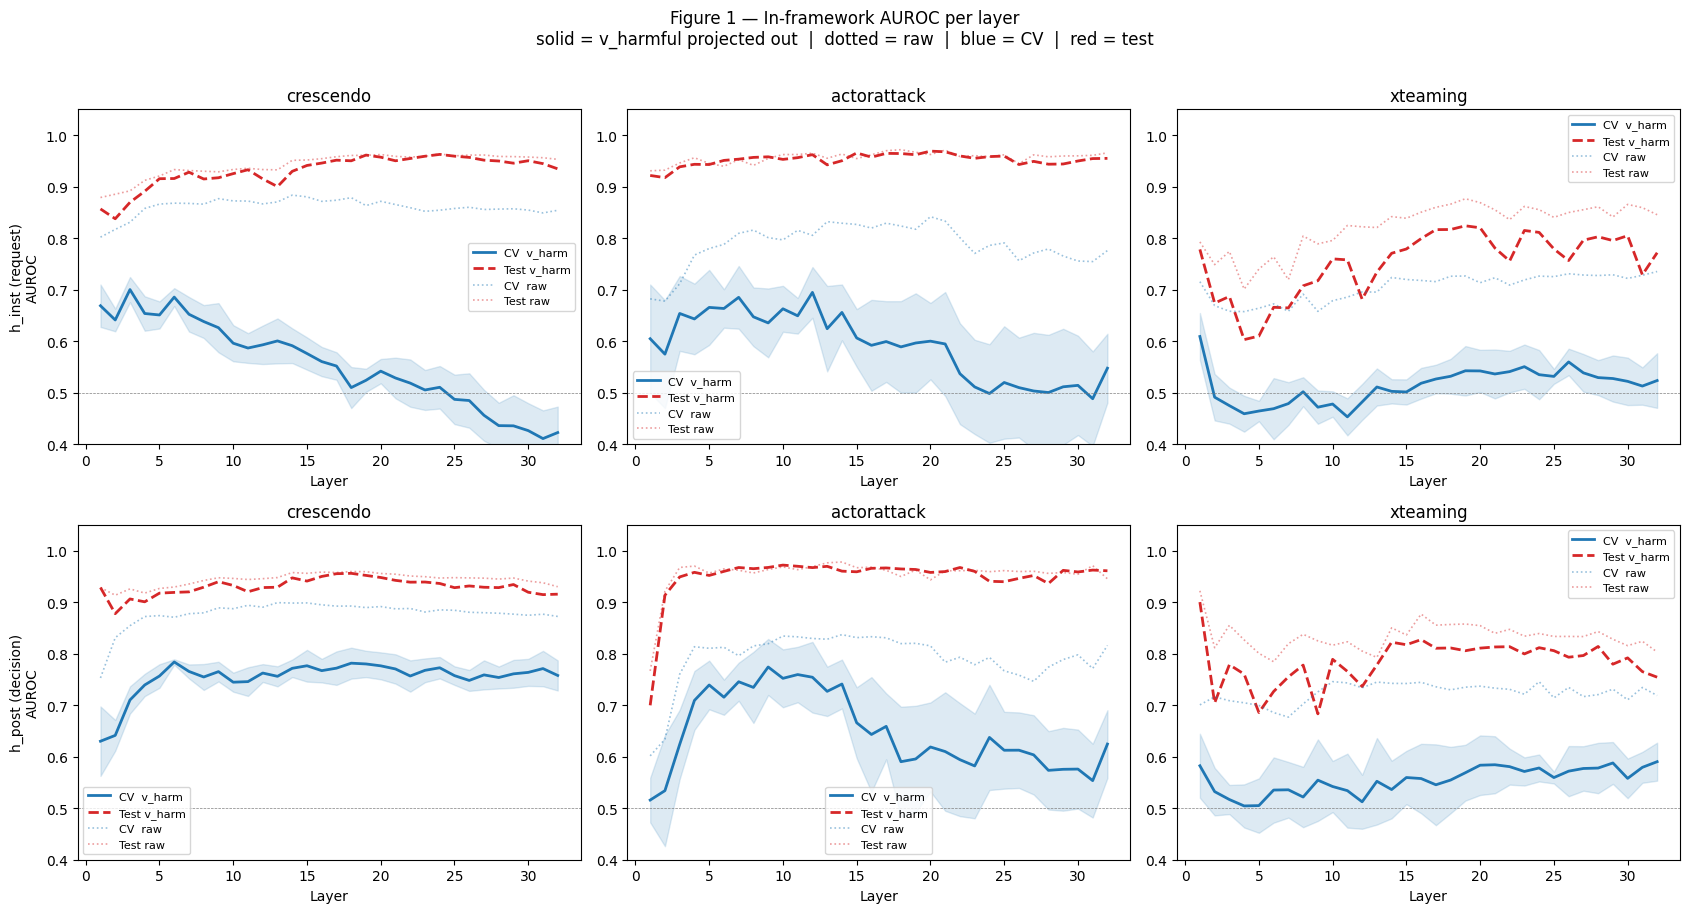

Saved figures/05_fig1_infw_auroc.png


In [37]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))

for row, h_key in enumerate(["h_inst", "h_post"]):
    for col, fw in enumerate(FRAMEWORKS):
        ax  = axes[row, col]
        raw = probe_results_raw[(fw,   h_key)]
        vh  = probe_results_vharm[(fw, h_key)]

        # v_harmful — solid + fill (primary)
        ax.fill_between(layers,
                        vh["cv_aucs"] - vh["cv_stds"],
                        vh["cv_aucs"] + vh["cv_stds"],
                        color="#1f77b4", alpha=0.15)
        ax.plot(layers, vh["cv_aucs"],   color="#1f77b4", lw=2.0,
                label="CV  v_harm")
        ax.plot(layers, vh["test_aucs"], color="#d62728", lw=2.0, ls="--",
                label="Test v_harm")

        # Raw — dotted, lighter
        ax.plot(layers, raw["cv_aucs"],   color="#1f77b4", lw=1.2, ls=":",
                alpha=0.45, label="CV  raw")
        ax.plot(layers, raw["test_aucs"], color="#d62728", lw=1.2, ls=":",
                alpha=0.45, label="Test raw")

        ax.axhline(0.5, color="gray", lw=0.5, ls="--")
        ax.set_ylim(0.4, 1.05)
        ax.set_xlabel("Layer")
        ax.set_title(fw)
        if col == 0:
            pos_label = "h_inst (request)" if h_key == "h_inst" else "h_post (decision)"
            ax.set_ylabel(f"{pos_label}\nAUROC")
        ax.legend(fontsize=8)

plt.suptitle(
    "Figure 1 — In-framework AUROC per layer\n"
    "solid = v_harmful projected out  |  dotted = raw  |  blue = CV  |  red = test",
    y=1.01,
)
plt.tight_layout()
plt.savefig("../figures/05_fig1_infw_auroc.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figures/05_fig1_infw_auroc.png")


## Figure 2 — Cross-framework transfer (v_harmful projected out)

Train on framework A, test on framework B, at best layer and last layer (L32).
Diagonal ★ = in-framework. Off-diagonal = cross-framework transfer.

High off-diagonal AUROC means compliance-state representations are shared across
frameworks after topic is removed. Low off-diagonal means framework-specific encoding.


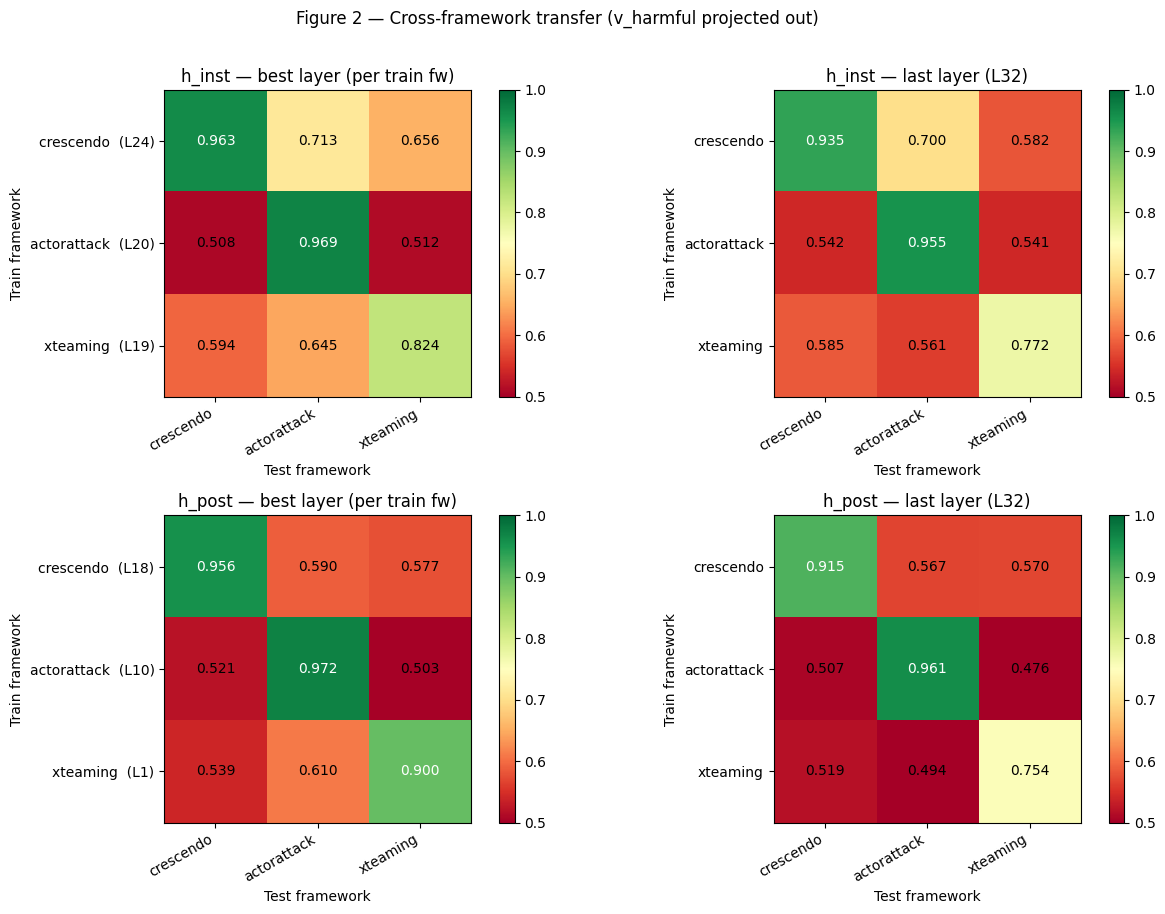

Saved figures/05_fig2_crossfw_transfer.png


In [38]:
LAST_LAYER = N_LAYERS - 1

transfer_vharm = {}

for h_key in ["h_inst", "h_post"]:
    mat_best = np.zeros((3, 3))
    mat_last = np.zeros((3, 3))

    for i, train_fw in enumerate(FRAMEWORKS):
        probes = probe_results_vharm[(train_fw, h_key)]["probes"]
        best_l = int(np.nanargmax(probe_results_vharm[(train_fw, h_key)]["test_aucs"]))

        for j, test_fw in enumerate(FRAMEWORKS):
            X_te, y_te, _ = build_dataset_vharm(test_fw, "test", h_key)
            mat_best[i, j] = roc_auc_score(y_te, probe_proba(X_te, probes, best_l))
            mat_last[i, j] = roc_auc_score(y_te, probe_proba(X_te, probes, LAST_LAYER))

    transfer_vharm[(h_key, "best")] = mat_best
    transfer_vharm[(h_key, "last")] = mat_last

best_layer_vh = {(fw, h_key): int(np.nanargmax(probe_results_vharm[(fw, h_key)]["test_aucs"]))
                 for fw in FRAMEWORKS for h_key in ["h_inst", "h_post"]}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
configs = [
    (axes[0,0], "h_inst", "best",  "h_inst — best layer (per train fw)"),
    (axes[0,1], "h_inst", "last",  f"h_inst — last layer (L{N_LAYERS})"),
    (axes[1,0], "h_post", "best",  "h_post — best layer (per train fw)"),
    (axes[1,1], "h_post", "last",  f"h_post — last layer (L{N_LAYERS})"),
]
for ax, h_key, which, title in configs:
    mat = transfer_vharm[(h_key, which)]
    im  = ax.imshow(mat, vmin=0.5, vmax=1.0, cmap="RdYlGn")
    if which == "best":
        ylabels = [f"{fw}  (L{best_layer_vh[(fw, h_key)]+1})" for fw in FRAMEWORKS]
    else:
        ylabels = FRAMEWORKS
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(FRAMEWORKS, rotation=30, ha="right")
    ax.set_yticklabels(ylabels)
    ax.set_xlabel("Test framework"); ax.set_ylabel("Train framework")
    ax.set_title(title)
    for ii in range(3):
        for jj in range(3):
            val = mat[ii, jj]
            ax.text(jj, ii, f"{val:.3f}", ha="center", va="center",
                    fontsize=10, color="black" if val < 0.85 else "white")
    plt.colorbar(im, ax=ax)

plt.suptitle("Figure 2 — Cross-framework transfer (v_harmful projected out)", y=1.01)
plt.tight_layout()
plt.savefig("../figures/05_fig2_crossfw_transfer.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figures/05_fig2_crossfw_transfer.png")


## Figures 3 & 4 — K-sweep: P(harmful) over turns

Probe trained on final-turn representations, applied turn-by-turn.
**Solid = PCA-removed, dashed = raw** on the same axes.
The gap between the two at turn 1 is the topic contribution to P(harmful);
the rising slope is compliance priming — present in both conditions but
cleaner after topic removal.

3×3 grid: rows = training framework, columns = test framework.
★ diagonal = in-framework. Off-diagonal = cross-framework transfer.


In [39]:
def plot_ksweep_comparison(h_key, fig_path, fig_title):
    """3×3 k-sweep: v_harmful projected out (solid) vs raw (dotted)."""
    MIN_CONVS = 5
    fig, axes = plt.subplots(3, 3, figsize=(16, 13))

    for row, train_fw in enumerate(FRAMEWORKS):
        best_vh  = int(np.nanargmax(probe_results_vharm[(train_fw, h_key)]["test_aucs"]))
        best_raw = int(np.nanargmax(probe_results_raw[(train_fw,   h_key)]["test_aucs"]))
        pr_vh    = probe_results_vharm[(train_fw, h_key)]["probes"]
        pr_raw   = probe_results_raw[(train_fw,   h_key)]["probes"]

        for col, test_fw in enumerate(FRAMEWORKS):
            ax = axes[row, col]

            for cat, goal_type, color, label in [
                ("accepted_harmful",  "harmful", "#d62728", "harmful"),
                ("accepted_harmless", "benign",  "#1f77b4", "harmless"),
            ]:
                meta   = traj[(test_fw, goal_type)]["meta"]
                h_arr  = traj[(test_fw, goal_type)][h_key]
                test_m = meta[meta["data_split"] == "test"]
                max_k  = int(test_m[test_m["category"] == cat]["turn_k"].max()) \
                         if (test_m["category"] == cat).any() else 0

                m_v, s_v, t_v = [], [], []
                m_r, s_r, t_r = [], [], []

                for k in range(1, max_k + 1):
                    rows_k = test_m[(test_m["category"] == cat) & (test_m["turn_k"] == k)]
                    if len(rows_k) < MIN_CONVS:
                        break
                    pos  = meta.index.get_indexer(rows_k.index)
                    X_k  = h_arr[pos].astype(np.float32)

                    p_v = probe_proba(vharm_h(X_k, train_fw, h_key), pr_vh,  best_vh)
                    p_r = probe_proba(X_k,                            pr_raw, best_raw)

                    m_v.append(p_v.mean()); s_v.append(p_v.std()/np.sqrt(len(p_v))); t_v.append(k)
                    m_r.append(p_r.mean()); s_r.append(p_r.std()/np.sqrt(len(p_r))); t_r.append(k)

                # v_harmful — solid + fill
                if m_v:
                    m = np.array(m_v); s = np.array(s_v)
                    ax.plot(t_v, m, color=color, lw=1.8, marker="o", ms=3,
                            label=f"{label} (v_harm)")
                    ax.fill_between(t_v, m-s, m+s, color=color, alpha=0.15)

                # Raw — dotted, faint
                if m_r:
                    m = np.array(m_r); s = np.array(s_r)
                    ax.plot(t_r, m, color=color, lw=1.0, ls=":", marker="s",
                            ms=2, alpha=0.4, label=f"{label} (raw)")

            ax.axhline(0.5, color="gray", lw=0.5, ls=":")
            ax.set_ylim(0.0, 1.05)
            ax.set_xlabel("Turn k")
            diag = "★ " if train_fw == test_fw else ""
            ax.set_title(f"{diag}Test: {test_fw}\n"
                         f"v_harm L{best_vh+1} / raw L{best_raw+1}", fontsize=8)
            ax.legend(fontsize=7)

        axes[row, 0].set_ylabel(f"Train: {train_fw}\nMean P(harmful)", fontsize=8)

    plt.suptitle(fig_title, y=1.01)
    plt.tight_layout()
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {fig_path}")


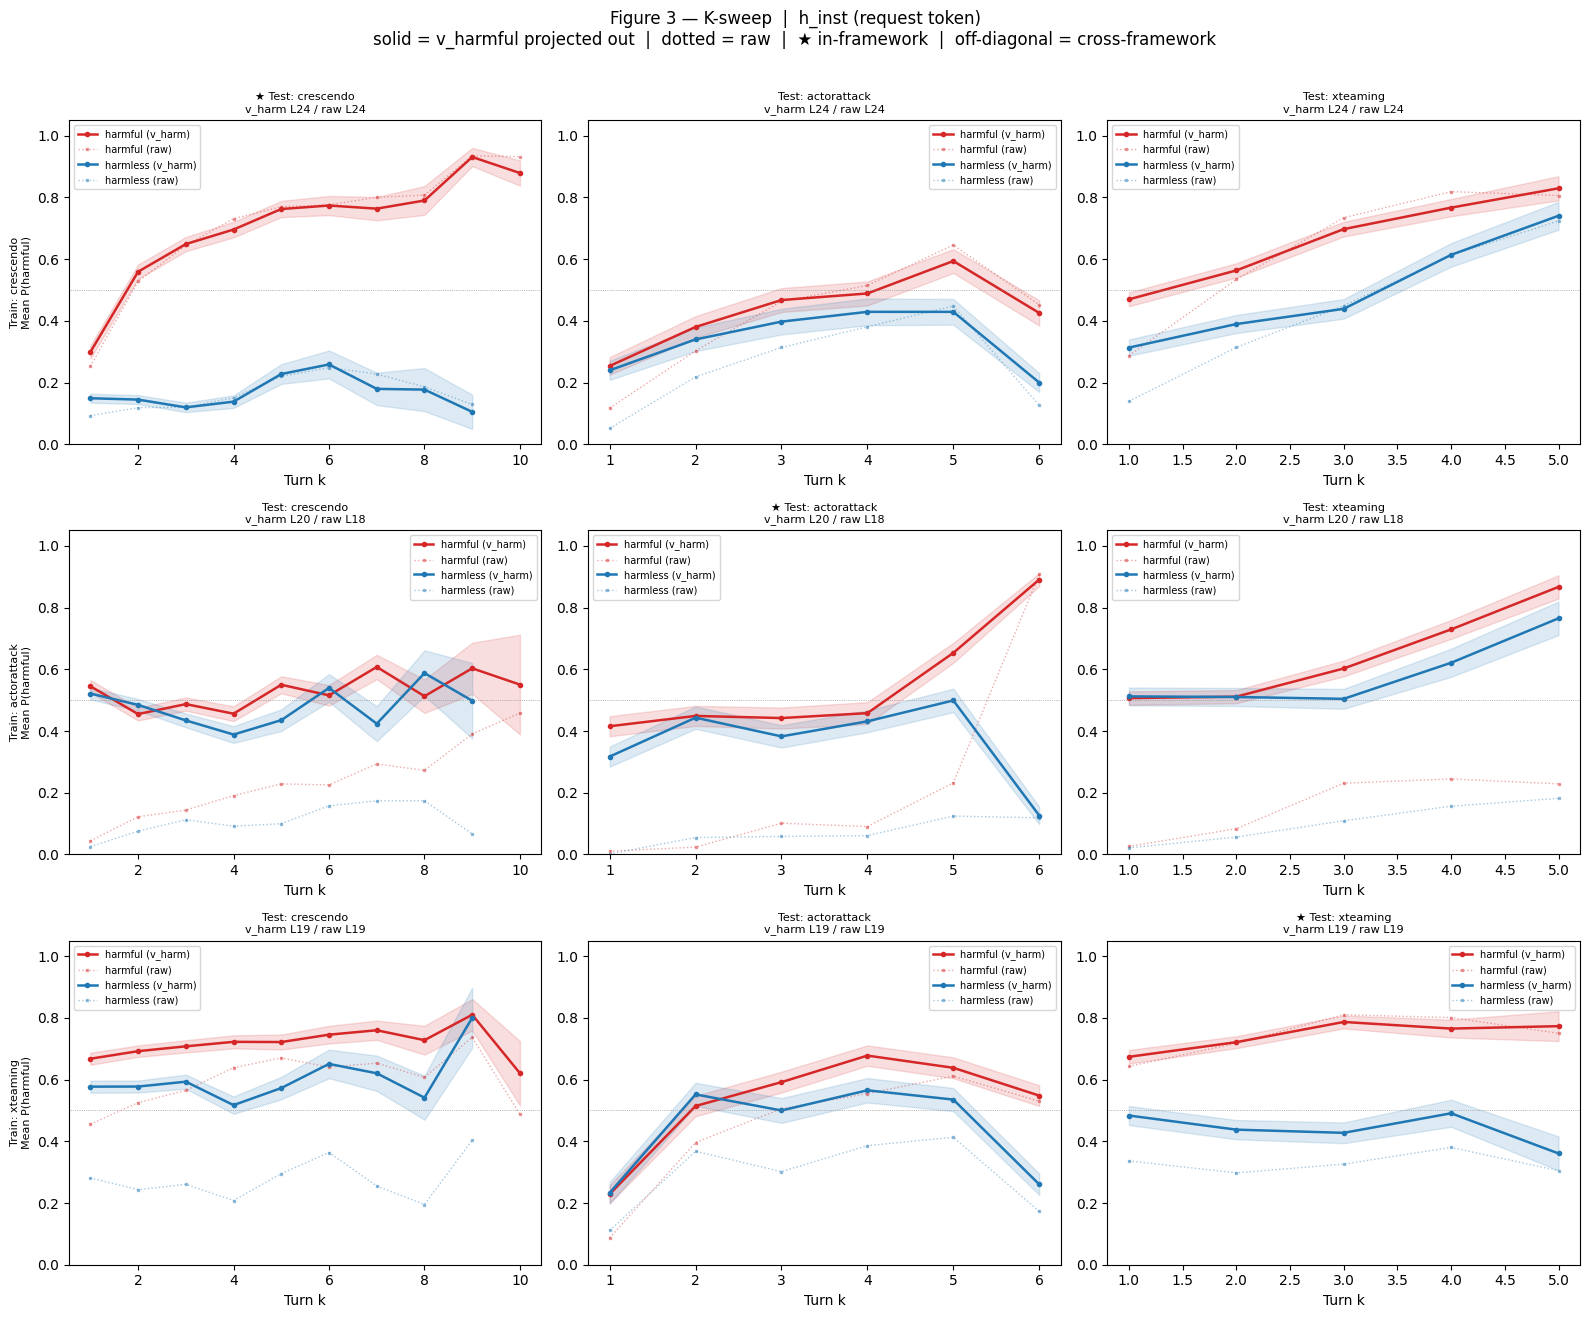

Saved ../figures/05_fig3_ksweep_hinst.png


In [40]:
plot_ksweep_comparison(
    h_key     = "h_inst",
    fig_path  = "../figures/05_fig3_ksweep_hinst.png",
    fig_title = (
        "Figure 3 — K-sweep  |  h_inst (request token)\n"
        "solid = v_harmful projected out  |  dotted = raw  |  "
        "★ in-framework  |  off-diagonal = cross-framework"
    ),
)


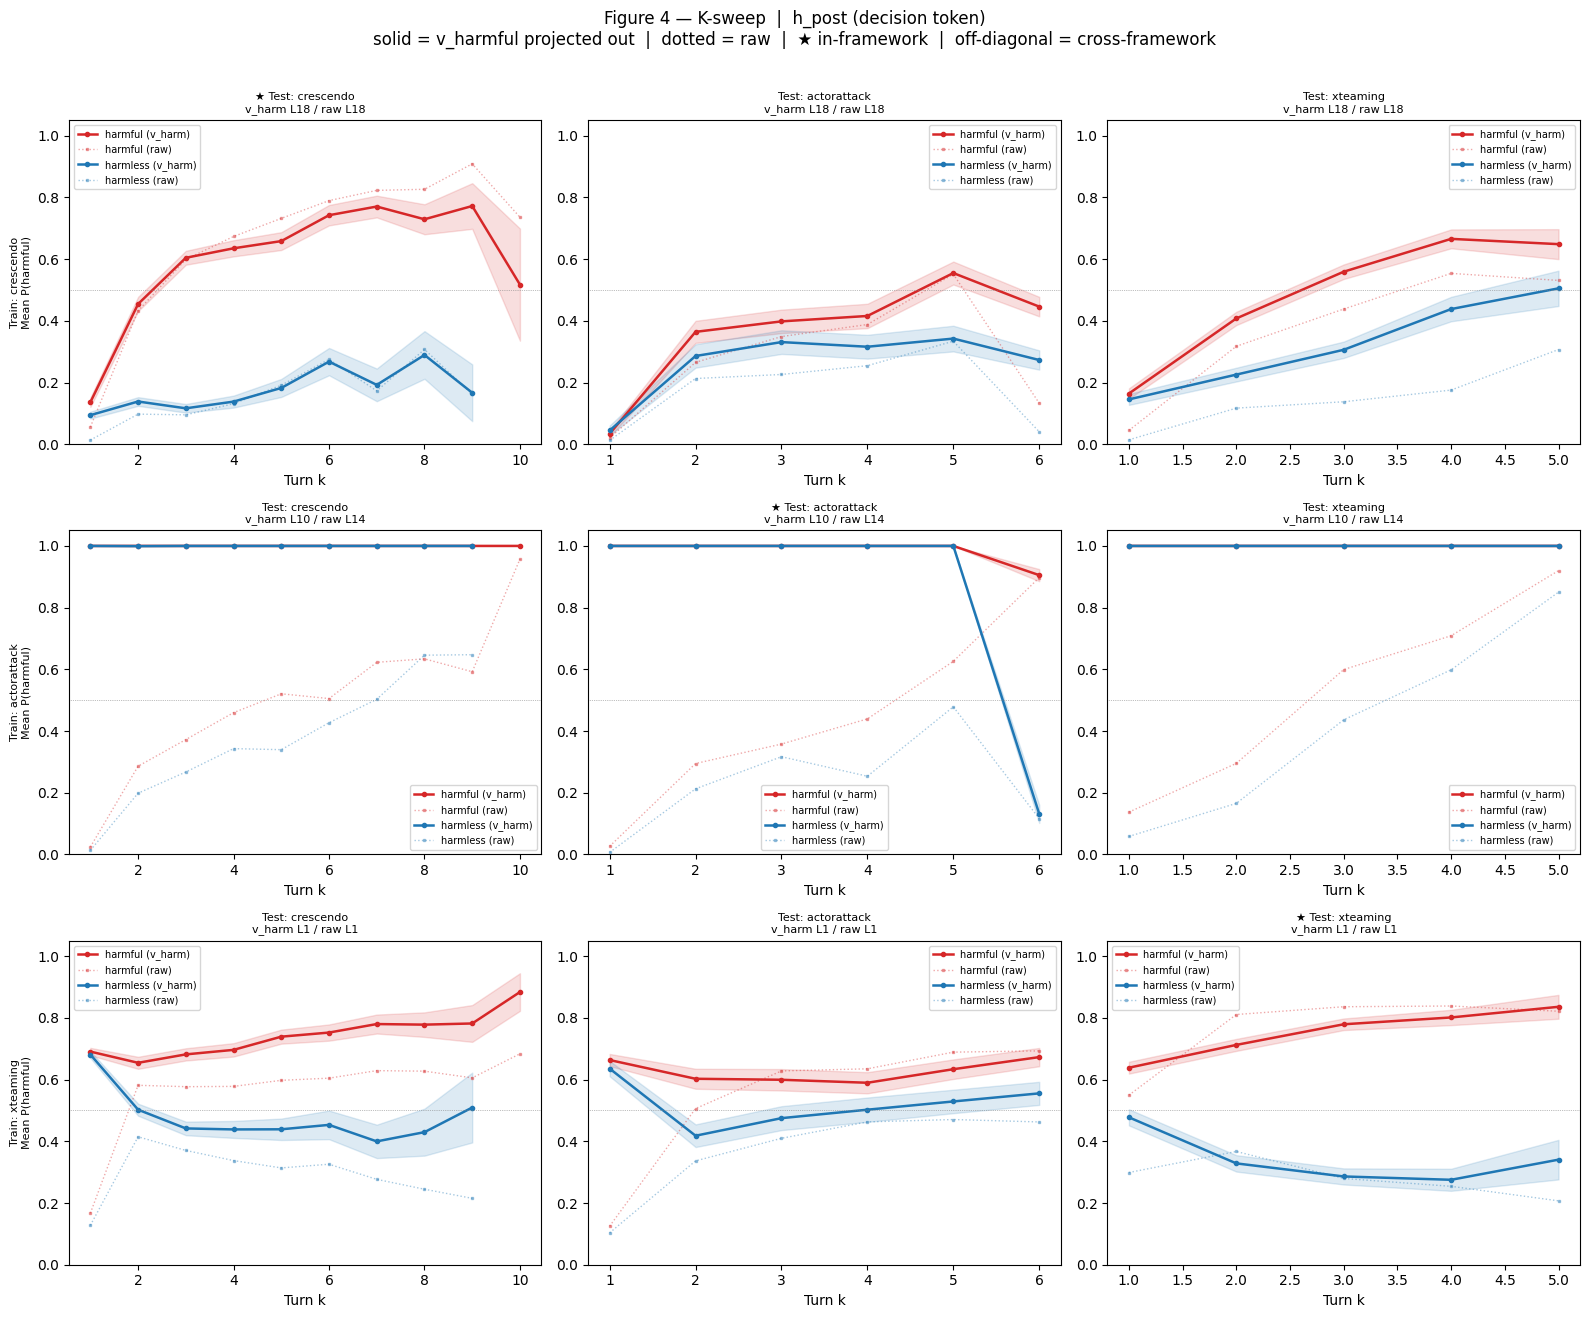

Saved ../figures/05_fig4_ksweep_hpost.png


In [41]:
plot_ksweep_comparison(
    h_key     = "h_post",
    fig_path  = "../figures/05_fig4_ksweep_hpost.png",
    fig_title = (
        "Figure 4 — K-sweep  |  h_post (decision token)\n"
        "solid = v_harmful projected out  |  dotted = raw  |  "
        "★ in-framework  |  off-diagonal = cross-framework"
    ),
)
